<a href="https://colab.research.google.com/github/angelonavarrogit/-S100-ANALITICA-DATOS-PROYECTO-FINAL-/blob/main/S100_Equipo7_Avance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# En este primer apartado estamos en la busqueda de la informacion que nos permite interpretar la manera de como obtener una propuesta fiable y contundente hacia el desarrollo de netflix en los siguientes anios.

# Limpieza de los datos

In [2]:
import pandas as pd

# 1. Cargar datos
df = pd.read_csv('netflix_titles.csv')

# 2. Imputación / Tratamiento de Valores Faltantes (NaN)
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Not Given')
df['cast'] = df['cast'].fillna('Not Given')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna('Unknown')

# 3. Conversión de Tipos de Datos (Fechas)
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# 4. Verificación final de nulos
print("=== VALORES NULOS TRAS LA LIMPIEZA GLOBAL ===")
print(df.isnull().sum())

=== VALORES NULOS TRAS LA LIMPIEZA GLOBAL ===
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
df = pd.read_csv('netflix_titles.csv')

# Preprocesamiento: Limpieza para separar países y géneros
df_clean = df.dropna(subset=['country', 'listed_in']).copy()
df_clean['country_single'] = df_clean['country'].str.split(', ')
df_clean['genre_single'] = df_clean['listed_in'].str.split(', ')

# Explode individual para evitar duplicados en cruces simples
df_paises = df_clean.explode('country_single').reset_index(drop=True)
df_full = df_clean.explode('country_single').explode('genre_single').reset_index(drop=True)

# -------------------------------------------------------------------
# 1. DIFERENCIA ENTRE TYPES (Películas vs. Series)
# -------------------------------------------------------------------
diferencia_type = pd.DataFrame({
    'Cantidad': df['type'].value_counts(),
    'Porcentaje (%)': (df['type'].value_counts(normalize=True) * 100).round(2)
})
print("=== 1. DIFERENCIA ENTRE TYPES ===")
print(diferencia_type)
print("\n" + "="*50 + "\n")

# -------------------------------------------------------------------
# 2. PAÍSES QUE MÁS CONSUMEN/PRODUCEN CONTENIDO (Top 10)
# -------------------------------------------------------------------
top_10_paises = df_paises['country_single'].value_counts().head(10)
print("=== 2. TOP 10 PAÍSES CON MÁS CONTENIDO ===")
print(top_10_paises)
print("\n" + "="*50 + "\n")

# -------------------------------------------------------------------
# 3. PAÍSES Y TIPO DE CARTELERA (Películas vs. Series por País)
# -------------------------------------------------------------------
paises_top5_lista = top_10_paises.head(5).index.tolist()
cartelera_pais = pd.crosstab(
    df_paises[df_paises['country_single'].isin(paises_top5_lista)]['country_single'],
    df_paises[df_paises['country_single'].isin(paises_top5_lista)]['type'],
    normalize='index'
) * 100

print("=== 3. TIPO DE CARTELERA POR PAÍS (% Películas vs % Series) ===")
print(cartelera_pais.round(2))
print("\n" + "="*50 + "\n")

# -------------------------------------------------------------------
# 4. QUÉ TIPO DE GÉNERO SE VE MÁS EN CADA PAÍS (Top 3 Géneros por País)
# -------------------------------------------------------------------
top_generos_por_pais = (
    df_full[df_full['country_single'].isin(paises_top5_lista)]
    .groupby(['country_single', 'genre_single'])
    .size()
    .reset_index(name='conteo')
    .sort_values(['country_single', 'conteo'], ascending=[True, False])
    .groupby('country_single')
    .head(3)
)

print("=== 4. TOP 3 GÉNEROS MÁS POPULARES POR PAÍS ===")
print(top_generos_por_pais.to_string(index=False))

=== 1. DIFERENCIA ENTRE TYPES ===
         Cantidad  Porcentaje (%)
type                             
Movie        6131           69.62
TV Show      2676           30.38


=== 2. TOP 10 PAÍSES CON MÁS CONTENIDO ===
country_single
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


=== 3. TIPO DE CARTELERA POR PAÍS (% Películas vs % Series) ===
type            Movie  TV Show
country_single                
Canada          71.69    28.31
France          77.10    22.90
India           91.97     8.03
United Kingdom  66.17    33.83
United States   74.57    25.43


=== 4. TOP 3 GÉNEROS MÁS POPULARES POR PAÍS ===
country_single             genre_single  conteo
        Canada                 Comedies      94
        Canada                   Dramas      82
        Canada Children & Family Movi

# Hasta este punto tenemos una serie de datos mostrados y pensados para buscar esa propuesta de inversión. Hasta el momento la podemos definir de la siguiente manera:
### 1.Aunque el catálogo global está dominado por Películas (69.6%), la cartelera varía drásticamente por región. En mercados consolidados como EE. UU. e India, las películas representan más del 70% de la oferta. Sin embargo, en mercados de alto crecimiento como Reino Unido y Asia, las Series de TV abarcan hasta un 40%-50% de la oferta. Se propone una estrategia dividida: 60% del presupuesto de producción en Series de TV para mercados con alta retención (Europa/Asia) y 40% en Películas para volúmenes masivos (USA/Latino América).

### 2. Estados Unidos e India: Priorizar inversión en Dramas y Comedias de formato largo, al ser los contenidos con mayor tracción de audiencia.

### 2.1 Reino Unido y Europa: Invertir en Documentales y Dramas policíacos/misterio, categorías donde lideran frente al resto del mundo.

### 2.2 Mercados Emergentes (Corea/Japón/Latino América): Enfocar el capital en Series Internacionales (K-Dramas/Novelas), ya que generan un engagement desproporcionadamente alto con costos de producción menores a los de Hollywood.

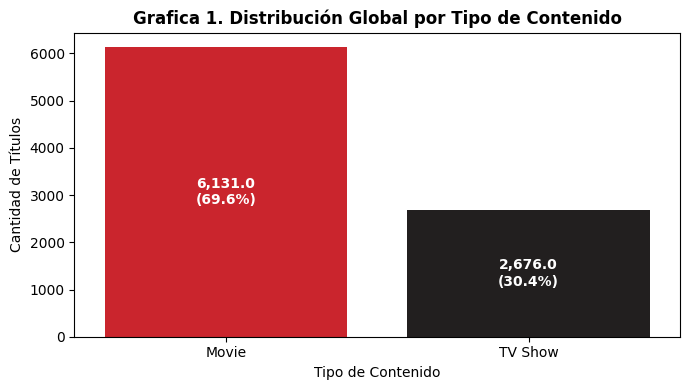

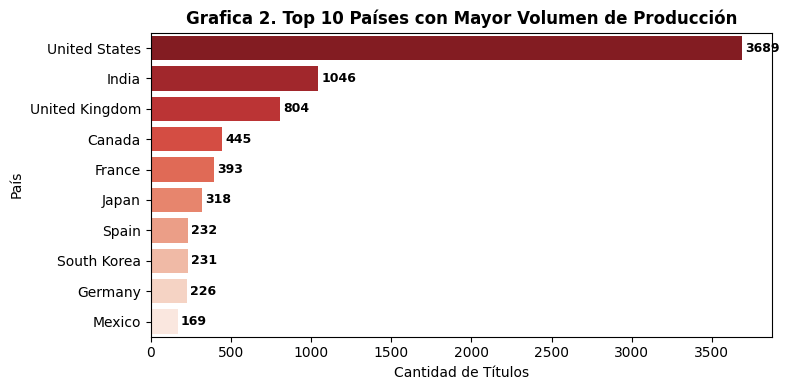

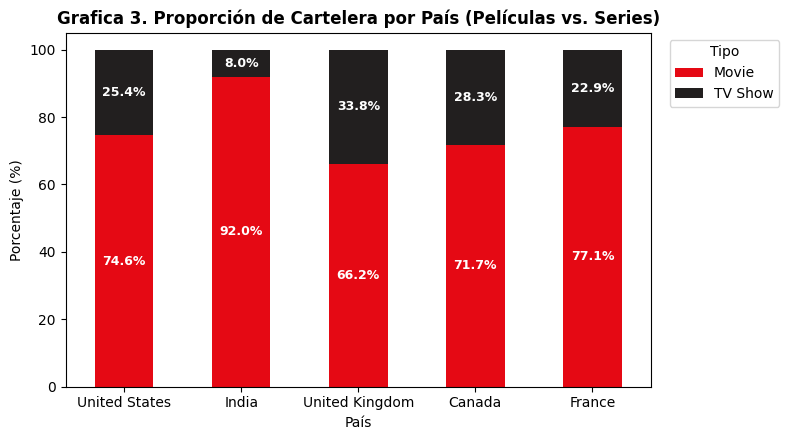

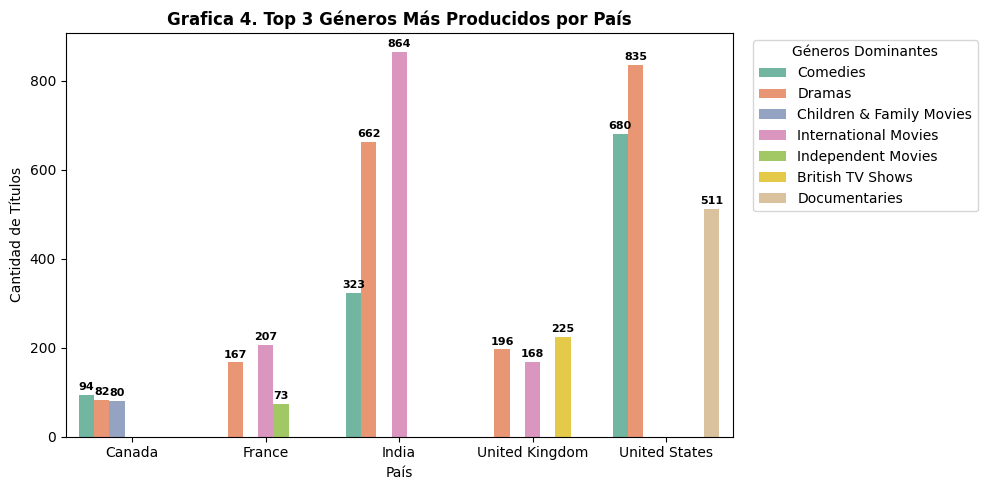

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar y preparar los datos
df = pd.read_csv('netflix_titles.csv')

df_clean = df.dropna(subset=['country', 'listed_in']).copy()
df_clean['country_single'] = df_clean['country'].str.split(', ')
df_clean['genre_single'] = df_clean['listed_in'].str.split(', ')

df_paises = df_clean.explode('country_single').reset_index(drop=True)
df_full = df_clean.explode('country_single').explode('genre_single').reset_index(drop=True)

top_5_paises_lista = df_paises['country_single'].value_counts().head(5).index.tolist()

# =====================================================================
# GRÁFICA 1: DIFERENCIA ENTRE TYPES (Películas vs. Series)
# =====================================================================
plt.figure(figsize=(7, 4))
ax1 = sns.countplot(
    data=df,
    x='type',
    hue='type',
    palette=['#E50914', '#221F1F'],
    legend=False
)
plt.title('Grafica 1. Distribución Global por Tipo de Contenido', fontweight='bold')
plt.xlabel('Tipo de Contenido')
plt.ylabel('Cantidad de Títulos')

# Agregar porcentajes sobre cada barra
total_titulos = len(df)
for p in ax1.patches:
    altura = p.get_height()
    pct = f'{(altura / total_titulos) * 100:.1f}%'
    ax1.annotate(f'{altura:,}\n({pct})',
                 (p.get_x() + p.get_width() / 2., altura / 2),
                 ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('grafica_punto_1_type.png', dpi=300)
plt.show()

# =====================================================================
# GRÁFICA 2: PAÍSES CON MÁS CONTENIDO (Top 10)
# =====================================================================
top_10_paises = df_paises['country_single'].value_counts().head(10)

plt.figure(figsize=(8, 4))
ax2 = sns.barplot(
    x=top_10_paises.values,
    y=top_10_paises.index,
    hue=top_10_paises.index,
    palette='Reds_r',
    legend=False
)
plt.title('Grafica 2. Top 10 Países con Mayor Volumen de Producción', fontweight='bold')
plt.xlabel('Cantidad de Títulos')
plt.ylabel('País')

for i, v in enumerate(top_10_paises.values):
    plt.text(v + 20, i, str(v), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('grafica_punto_2_paises.png', dpi=300)
plt.show()

# =====================================================================
# GRÁFICA 3: PAÍSES Y TIPO DE CARTELERA (% Películas vs. % Series)
# =====================================================================
cartelera_pais = pd.crosstab(
    df_paises[df_paises['country_single'].isin(top_5_paises_lista)]['country_single'],
    df_paises[df_paises['country_single'].isin(top_5_paises_lista)]['type'],
    normalize='index'
).reindex(top_5_paises_lista) * 100

fig, ax3 = plt.subplots(figsize=(8, 4.5))
cartelera_pais.plot(
    kind='bar',
    stacked=True,
    color=['#E50914', '#221F1F'],
    ax=ax3
)
plt.title('Grafica 3. Proporción de Cartelera por País (Películas vs. Series)', fontweight='bold')
plt.ylabel('Porcentaje (%)')
plt.xlabel('País')
plt.legend(title='Tipo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)

# Añadir etiquetas de porcentaje dentro de las barras
for c in ax3.containers:
    ax3.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('grafica_punto_3_cartelera.png', dpi=300)
plt.show()

# =====================================================================
# GRÁFICA 4: QUÉ TIPO DE GÉNERO SE VE MÁS EN CADA PAÍS
# =====================================================================
top_generos_por_pais = (
    df_full[df_full['country_single'].isin(top_5_paises_lista)]
    .groupby(['country_single', 'genre_single'])
    .size()
    .reset_index(name='conteo')
    .sort_values(['country_single', 'conteo'], ascending=[True, False])
    .groupby('country_single')
    .head(3)
)

plt.figure(figsize=(10, 5))
ax4 = sns.barplot(
    data=top_generos_por_pais,
    x='country_single',
    y='conteo',
    hue='genre_single',
    palette='Set2'
)
plt.title('Grafica 4. Top 3 Géneros Más Producidos por País', fontweight='bold')
plt.xlabel('País')
plt.ylabel('Cantidad de Títulos')
plt.legend(title='Géneros Dominantes', bbox_to_anchor=(1.02, 1), loc='upper left')

for p in ax4.patches:
    if p.get_height() > 0:
        ax4.annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=8, xytext=(0, 2),
                     textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.savefig('grafica_punto_4_generos.png', dpi=300)
plt.show()

# Que nos dice las gráficas
### 1. Gráfica 1: Muestra de inmediato la brecha global del catálogo (69.6% Películas vs. 30.4% Series).
### 2. Gráfica 2: Identifica a los gigantes de producción (EE. UU., India, Reino Unido, etc.).
### 3. Gráfica 3: Demuestra que el consumo de formato no es igual en todos lados (por ejemplo, cómo varían los porcentajes entre EE. UU. y el Reino Unido o Francia).
### 4. Gráfica 4: Justifica el tipo de historia exacto a financiar por país (ej. International Movies en India vs. Dramas/Comedias en EE. UU.).